# Notebook 03 - Modelado

**Responsable:** jeorregog1  
**Bloque:** baseline + LightGBM + tuning

Este notebook parte de los archivos procesados generados en `02_preprocessing.ipynb` y se limita estrictamente al bloque de modelado del Integrante 2:

1. cargar los splits `train / val` ya preparados
2. entrenar uno o más baselines de referencia
3. entrenar un modelo principal con **LightGBM**
4. ajustar hiperparámetros usando validación separada
5. guardar el mejor modelo y los artefactos de tuning para handoff

> Nota: el proyecto quedó orientado a **predicción binaria de deserción estudiantil**, consistente con la opción 1 definida por el equipo.
>
> El **test set** queda reservado para el Integrante 3, quien se encarga de métricas finales, comparación formal de modelos y análisis de errores.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

In [2]:
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_DIR = ROOT / 'data' / 'processed'
MODEL_DIR = ROOT / 'models'
FIGURE_DIR = DATA_DIR
CHECKPOINT_DIR = MODEL_DIR / 'checkpoints'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(DATA_DIR / 'X_train.csv')
X_val = pd.read_csv(DATA_DIR / 'X_val.csv')

y_train = pd.read_csv(DATA_DIR / 'y_train.csv')['Target_Binary']
y_val = pd.read_csv(DATA_DIR / 'y_val.csv')['Target_Binary']

X_trainval = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_trainval = pd.concat([y_train, y_val], axis=0, ignore_index=True)

print('Shapes:')
print(f'  X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape} | y_val:   {y_val.shape}')
print(f'  Tasa de dropout en train: {y_train.mean():.3f}')
print(f'  Tasa de dropout en val:   {y_val.mean():.3f}')

Shapes:
  X_train: (3096, 34) | y_train: (3096,)
  X_val:   (664, 34) | y_val:   (664,)
  Tasa de dropout en train: 0.321
  Tasa de dropout en val:   0.322


In [3]:
def evaluate_binary_classifier(model, X, y, model_name, split_name):
    y_pred = model.predict(X)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X)[:, 1]
    else:
        y_score = y_pred

    return {
        'model': model_name,
        'split': split_name,
        'accuracy': accuracy_score(y, y_pred),
        'precision': precision_score(y, y_pred, zero_division=0),
        'recall': recall_score(y, y_pred, zero_division=0),
        'f1': f1_score(y, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y, y_score),
    }

## 1. Baselines

Se usan dos referencias sencillas:

- `dummy_prior`: establece el piso mínimo del problema.
- `logreg_balanced`: baseline lineal competitivo y fácil de interpretar.

La comparación inicial se hace sobre el **conjunto de validación**, sin tocar el test set.

In [4]:
baseline_models = {
    'dummy_prior': DummyClassifier(strategy='prior', random_state=RANDOM_STATE),
    'logreg_balanced': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE),
}

validation_results = []

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    validation_results.append(
        evaluate_binary_classifier(model, X_val, y_val, model_name=model_name, split_name='validation')
    )

validation_results_df = pd.DataFrame(validation_results).sort_values('f1', ascending=False)
validation_results_df.round(4)

,model,split,accuracy,precision,recall,f1,roc_auc
1,logreg_balanced,validation,0.8705,0.7807,0.8318,0.8054,0.9259
0,dummy_prior,validation,0.6777,0.0000,0.0000,0.0000,0.5000


## 2. LightGBM base

Decisiones heredadas del EDA y preprocessing:

- el problema presenta **desbalance de clases**
- se recomienda usar `class_weight='balanced'`
- LightGBM es adecuado para datos tabulares con relaciones no lineales
- la comparación se sigue haciendo contra validación

In [5]:
lgbm_default = LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    n_jobs=1,
    verbosity=-1,
)

lgbm_default.fit(X_train, y_train)
validation_results.append(
    evaluate_binary_classifier(lgbm_default, X_val, y_val, model_name='lightgbm_default', split_name='validation')
)

validation_results_df = pd.DataFrame(validation_results).sort_values('f1', ascending=False)
validation_results_df.round(4)

,model,split,accuracy,precision,recall,f1,roc_auc
1,logreg_balanced,validation,0.8705,0.7807,0.8318,0.8054,0.9259
2,lightgbm_default,validation,0.8614,0.8020,0.7570,0.7788,0.9215
0,dummy_prior,validation,0.6777,0.0000,0.0000,0.0000,0.5000


## 3. Tuning con validación separada

Para respetar la metodología del proyecto, el ajuste de hiperparámetros se hace usando **train + val** con un `PredefinedSplit`:

- las filas originales de `train` se usan para entrenar cada candidato
- las filas originales de `val` se usan para comparar candidatos
- el **test set queda completamente reservado para el Integrante 3**

La métrica principal de búsqueda será **F1**, apoyada por `roc_auc`, `recall` y `precision`.

In [6]:
validation_fold = np.concatenate([
    np.full(len(X_train), -1),
    np.zeros(len(X_val), dtype=int),
])

predefined_split = PredefinedSplit(test_fold=validation_fold)

search_space = {
    'n_estimators': [200, 300, 400, 500, 700],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 5, 8, 12],
    'min_child_samples': [10, 20, 40, 60],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.0, 0.1, 0.5, 1.0],
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

tuner = RandomizedSearchCV(
    estimator=LGBMClassifier(
        objective='binary',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
    ),
    param_distributions=search_space,
    n_iter=20,
    scoring=scoring,
    cv=predefined_split,
    random_state=RANDOM_STATE,
    n_jobs=1,
    refit='f1',
    verbose=1,
)

tuner.fit(X_trainval, y_trainval)
best_lgbm = tuner.best_estimator_
cv_results_df = pd.DataFrame(tuner.cv_results_).sort_values('rank_test_f1').reset_index(drop=True)
best_cv_row = cv_results_df.iloc[0]
tuned_validation_result = {
    'model': 'lightgbm_tuned',
    'split': 'validation',
    'accuracy': float(best_cv_row['mean_test_accuracy']),
    'precision': float(best_cv_row['mean_test_precision']),
    'recall': float(best_cv_row['mean_test_recall']),
    'f1': float(best_cv_row['mean_test_f1']),
    'roc_auc': float(best_cv_row['mean_test_roc_auc']),
}
validation_results_with_tuned_df = (
    pd.concat([validation_results_df, pd.DataFrame([tuned_validation_result])], ignore_index=True)
    .sort_values('f1', ascending=False)
    .reset_index(drop=True)
)

print('Mejores hiperparámetros encontrados:')
print(json.dumps(tuner.best_params_, indent=2, ensure_ascii=False))
print(f'\nMejor F1 en validación: {tuner.best_score_:.4f}')

Fitting 1 folds for each of 20 candidates, totalling 20 fits
Mejores hiperparámetros encontrados:
{
  "subsample": 0.9,
  "reg_lambda": 0.5,
  "reg_alpha": 0.0,
  "num_leaves": 127,
  "n_estimators": 300,
  "min_child_samples": 10,
  "max_depth": 5,
  "learning_rate": 0.1,
  "colsample_bytree": 0.7
}

Mejor F1 en validación: 0.8057


## 4. Artefactos del bloque de modelado

En este punto termina el alcance de `jeorregog1`.

Aquí se dejan listos los artefactos que sí te corresponden:

- comparación de candidatos sobre validación
- mejores hiperparámetros del modelo principal
- resultados completos del tuning
- modelo LightGBM guardado para handoff

La evaluación final en `test`, la comparación formal para el informe y el análisis de errores quedan reservados para el Integrante 3.

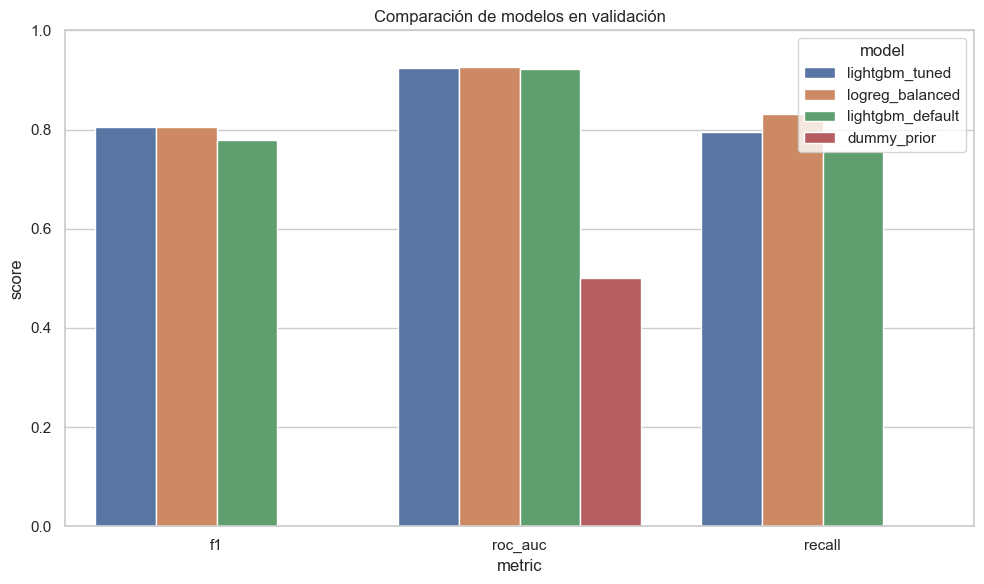

,model,split,accuracy,precision,recall,f1,roc_auc
0,lightgbm_tuned,validation,0.8765,0.8173,0.7944,0.8057,0.9235
1,logreg_balanced,validation,0.8705,0.7807,0.8318,0.8054,0.9259
2,lightgbm_default,validation,0.8614,0.8020,0.7570,0.7788,0.9215
3,dummy_prior,validation,0.6777,0.0000,0.0000,0.0000,0.5000


In [7]:
validation_results_with_tuned_df.to_csv(MODEL_DIR / 'metrics_validation_candidates.csv', index=False)
cv_results_df.to_csv(MODEL_DIR / 'lightgbm_tuning_results.csv', index=False)

with open(MODEL_DIR / 'lightgbm_best_params.json', 'w', encoding='utf-8') as f:
    json.dump(tuner.best_params_, f, indent=2, ensure_ascii=False)

joblib.dump(best_lgbm, CHECKPOINT_DIR / 'lightgbm_dropout_model.pkl')

best_validation_row = validation_results_with_tuned_df.iloc[0].to_dict()
handoff_summary = {
    'owner': 'jeorregog1',
    'problem_type': 'binary_classification_dropout',
    'selection_metric': 'f1',
    'best_validation_candidate': best_validation_row,
    'best_tuned_validation_metrics': tuned_validation_result,
    'lightgbm_best_params_path': 'models/lightgbm_best_params.json',
    'lightgbm_tuning_results_path': 'models/lightgbm_tuning_results.csv',
    'validation_metrics_path': 'models/metrics_validation_candidates.csv',
    'best_model_path': 'models/checkpoints/lightgbm_dropout_model.pkl',
    'validation_figure_path': 'data/processed/fig8_validation_model_comparison.png'
}

with open(MODEL_DIR / 'modeling_handoff_summary.json', 'w', encoding='utf-8') as f:
    json.dump(handoff_summary, f, indent=2, ensure_ascii=False)

comparison_df = validation_results_with_tuned_df.melt(
    id_vars='model',
    value_vars=['f1', 'roc_auc', 'recall'],
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='metric', y='score', hue='model')
plt.ylim(0, 1)
plt.title('Comparación de modelos en validación')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'fig8_validation_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

validation_results_with_tuned_df.round(4)

## Entregables esperados del bloque de modelado

Al correrlo deberían quedar generados estos artefactos:

- `models/metrics_validation_candidates.csv`
- `models/lightgbm_best_params.json`
- `models/lightgbm_tuning_results.csv`
- `models/modeling_handoff_summary.json`
- `models/checkpoints/lightgbm_dropout_model.pkl`
- `data/processed/fig8_validation_model_comparison.png`
